<a href="https://colab.research.google.com/github/SamaaHassan/IEEE-Data-Science/blob/main/Hotel_Bookings_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **📊 Hotel Bookings Analysis & Insights Report**

# 📊 Hotel Bookings Analysis & Insights Report

### 🎯 Objective
This report analyzes hotel booking data (Resort Hotel & City Hotel) to understand customer behavior, extract seasonal and financial patterns, and identify key factors influencing cancellations. The goal is to provide data-driven insights that assist hotel management in optimizing marketing and operational decisions to mitigate cancellation rates and maximize revenue.

---

### 🛠️ 1. Data Summary & Cleaning
* **Data Volume & Integration:** The datasets (`H1.csv` and `H2.csv`) were successfully combined using Pandas, resulting in a comprehensive dataset of **119,390 rows** and **32 columns**.
* **Preprocessing:** Handled missing values (e.g., in countries and market segments), removed outliers in room prices (`ADR`) to ensure statistical accuracy, and engineered custom features such as `IsFamily`.

---

### 🔍 2. Answering Business Questions

#### **Q1: What is the average lead time?**
* **Mean Lead Time:** **80.7 days**
* **Median Lead Time:** **50.0 days**
* **Standard Deviation:** **85.9 days**
* **Statistical Insight:** The notable difference between the Mean (80.7) and Median (50) confirms that the data distribution is **Right-Skewed**. The high Standard Deviation (85.9) indicates significant variance in customer behavior; some guests book days before arrival, while others book over six months in advance. The latter segment requires special attention as they are highly susceptible to cancellation.

#### **Q2: Which hotel type receives more bookings?**
* **Answer:** **City Hotel** receives significantly more bookings than Resort Hotel.
* **Metrics:**
  * **City Hotel:** **52,321** bookings (**61.1%**)
  * **Resort Hotel:** **33,265** bookings (**38.9%**)
* **Business Insight:** The operational and staffing demand heavily leans toward the City Hotel, requiring dynamic room inventory management.

#### **Q3: Which months have the highest reservations?**
* **Answer:** **August** is the absolute peak month with **11,099 bookings**, closely followed by **July** with **9,899 bookings**.
* **Business Insight:** July and August represent the **High Season** for the hotel, whereas the winter months, specifically January (4,572 bookings), represent the lowest demand period.

#### **Q4: What factors affect cancellations?**
* **Overall Cancellation Rate:** Based on the data analysis, the baseline cancellation rate is a critical metric for the hotel.
* **Key Drivers Identified:**
  1. **Booking Channel (Market Segment):** Online Travel Agencies (**Online TA**) suffer from exceptionally high cancellation rates (exceeding **35%**) due to frictionless "free cancellation" policies.
  2. **Lead Time:** A strong positive correlation exists; the further in advance a guest books, the higher the likelihood of cancellation due to changing plans.
  3. **Price & Seasonality (ADR):** Room prices peak sharply during summer months. This high pricing directly synchronizes with elevated cancellation rates, indicating that premium prices trigger customer churn.
  4. **Customer History:** Guests WITH previous cancellations have a drastically higher probability of canceling their new bookings compared to loyal, first-time, or repeated guests.
  5. **Special Requests:** A powerful inverse relationship was discovered; guests who submit special requests exhibit near-zero cancellation rates, demonstrating high booking commitment.

#### **Q5: Which countries generate the largest number of bookings?**
* **Answer:** The European market dominates the demand, with **Portugal (PRT)** leading by a massive margin. The top 5 countries are:
  1. **Portugal (PRT):** 26,026 bookings (**30.6%**)
  2. **United Kingdom (GBR):** 10,360 bookings (**12.2%**)
  3. **France (FRA):** 8,785 bookings (**10.3%**)
  4. **Spain (ESP):** 7,181 bookings (**8.4%**)
  5. **Germany (DEU):** 5,366 bookings (**6.3%**)
* **Business Insight:** Nearly one-third of the total guests originate from Portugal alone, making it the primary target for marketing campaigns.

---

### 📉 3. Key Factors Affecting Cancellations
Based on the Exploratory Data Analysis (EDA), the most critical drivers of cancellations were identified:
1. **Booking Channel (Market Segment):** Online Travel Agencies (**Online TA**) suffer from exceptionally high cancellation rates (exceeding **35%**) due to the frictionless "free cancellation" policies typical of online platforms.
2. **Lead Time:** A strong positive correlation exists; the further in advance a guest books, the higher the likelihood of cancellation due to changing plans or finding better alternatives.
3. **Price & Seasonality (ADR):** Room prices peak sharply during summer months. This high pricing directly synchronizes with elevated cancellation rates, indicating that premium prices trigger budget-conscious customer churn.
4. **Special Requests:** A powerful inverse relationship was discovered; guests who submit special requests (e.g., extra beds, specific views) exhibit near-zero cancellation rates, demonstrating high booking commitment.



In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_resort=pd.read_csv('H1.csv')
df_city=pd.read_csv('H2.csv')

In [3]:
df_resort['hotel']='Resort Hotel'
df_city['hotel']='City Hotel'

print(df_resort.shape)
print(df_city.shape)

(40060, 32)
(79330, 32)


In [6]:
df_combined=pd.concat([df_resort,df_city],ignore_index=True)
df_combined.shape

(119390, 32)

# **Dtat Undersatnding**

In [38]:
df=df_combined

In [39]:
df.head(10)

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,hotel
0,0,342,2015,July,27,1,0,0,2,0.0,...,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01,Resort Hotel
1,0,737,2015,July,27,1,0,0,2,0.0,...,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01,Resort Hotel
2,0,7,2015,July,27,1,0,1,1,0.0,...,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02,Resort Hotel
3,0,13,2015,July,27,1,0,1,1,0.0,...,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02,Resort Hotel
4,0,14,2015,July,27,1,0,2,2,0.0,...,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03,Resort Hotel
5,0,14,2015,July,27,1,0,2,2,0.0,...,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03,Resort Hotel
6,0,0,2015,July,27,1,0,2,2,0.0,...,NULL,NULL,0,Transient,107.0,0,0,Check-Out,2015-07-03,Resort Hotel
7,0,9,2015,July,27,1,0,2,2,0.0,...,303,NULL,0,Transient,103.0,0,1,Check-Out,2015-07-03,Resort Hotel
8,1,85,2015,July,27,1,0,3,2,0.0,...,240,NULL,0,Transient,82.0,0,1,Canceled,2015-05-06,Resort Hotel
9,1,75,2015,July,27,1,0,3,2,0.0,...,15,NULL,0,Transient,105.5,0,0,Canceled,2015-04-22,Resort Hotel


In [17]:
df.tail()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,hotel
119385,0,23,2017,August,35,30,2,5,2,0.0,...,394,NULL,0,Transient,96.14,0,0,Check-Out,2017-09-06,City Hotel
119386,0,102,2017,August,35,31,2,5,3,0.0,...,9,NULL,0,Transient,225.43,0,2,Check-Out,2017-09-07,City Hotel
119387,0,34,2017,August,35,31,2,5,2,0.0,...,9,NULL,0,Transient,157.71,0,4,Check-Out,2017-09-07,City Hotel
119388,0,109,2017,August,35,31,2,5,2,0.0,...,89,NULL,0,Transient,104.40,0,0,Check-Out,2017-09-07,City Hotel
119389,0,205,2017,August,35,29,2,7,2,0.0,...,9,NULL,0,Transient,151.20,0,2,Check-Out,2017-09-07,City Hotel


In [18]:
df.sample(10)

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,hotel
100381,0,208,2016,October,44,23,2,2,2,0.0,...,9,NULL,0,Transient-Party,88.77,0,2,Check-Out,2016-10-27,City Hotel
42494,1,55,2015,September,37,6,2,0,2,0.0,...,1,NULL,0,Transient-Party,75.00,0,0,Canceled,2015-09-05,City Hotel
9486,1,183,2016,December,49,3,2,1,2,0.0,...,38,NULL,0,Transient,72.00,0,0,Canceled,2016-10-26,Resort Hotel
11072,1,65,2017,April,16,17,1,0,2,0.0,...,240,NULL,0,Transient,90.00,0,1,Canceled,2017-02-15,Resort Hotel
98024,0,238,2016,September,39,20,0,4,2,0.0,...,16,NULL,0,Transient-Party,107.00,0,1,Check-Out,2016-09-24,City Hotel
49740,1,104,2016,April,17,18,1,3,2,0.0,...,9,NULL,0,Transient,72.25,0,1,Canceled,2016-02-01,City Hotel
100145,0,153,2016,October,43,17,2,5,3,0.0,...,9,NULL,0,Transient,151.20,0,3,Check-Out,2016-10-24,City Hotel
56025,1,142,2016,August,35,27,0,1,2,2.0,...,9,NULL,0,Transient,168.30,0,2,Canceled,2016-08-26,City Hotel
69799,1,15,2017,June,23,7,0,1,1,0.0,...,484,NULL,0,Transient-Party,130.00,0,0,Canceled,2017-06-06,City Hotel
15515,0,40,2015,July,30,21,0,3,2,0.0,...,241,NULL,0,Transient,123.20,0,1,Check-Out,2015-07-24,Resort Hotel


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   IsCanceled                   119390 non-null  int64  
 1   LeadTime                     119390 non-null  int64  
 2   ArrivalDateYear              119390 non-null  int64  
 3   ArrivalDateMonth             119390 non-null  object 
 4   ArrivalDateWeekNumber        119390 non-null  int64  
 5   ArrivalDateDayOfMonth        119390 non-null  int64  
 6   StaysInWeekendNights         119390 non-null  int64  
 7   StaysInWeekNights            119390 non-null  int64  
 8   Adults                       119390 non-null  int64  
 9   Children                     119386 non-null  float64
 10  Babies                       119390 non-null  int64  
 11  Meal                         119390 non-null  object 
 12  Country                      118902 non-null  object 
 13 

In [78]:
df.describe

<bound method NDFrame.describe of         IsCanceled  LeadTime  ArrivalDateYear ArrivalDateMonth  \
2                0         7             2015             July   
3                0        13             2015             July   
4                0        14             2015             July   
6                0         0             2015             July   
7                0         9             2015             July   
...            ...       ...              ...              ...   
119385           0        23             2017           August   
119386           0       102             2017           August   
119387           0        34             2017           August   
119388           0       109             2017           August   
119389           0       205             2017           August   

        ArrivalDateWeekNumber  ArrivalDateDayOfMonth  StaysInWeekendNights  \
2                          27                      1                     0   
3                          27                      1                     0   
4                          27                      1                     0   
6                          27                      1                     0   
7                          27                      1                     0   
...                       ...                    ...                   ...   
119385                     35                     30                     2   
119386                     35                     31                     2   
119387                     35                     31                     2   
119388                     35                     31                     2   
119389                     35                     29                     2   

        StaysInWeekNights  Adults  Children  ...  RequiredCarParkingSpaces  \
2                       1       1       0.0  ...                         0   
3                       1       1       0.0  ...                         0   
4                       2       2       0.0  ...                         0   
6                       2       2       0.0  ...                         0   
7                       2       2       0.0  ...                         0   
...                   ...     ...       ...  ...                       ...   
119385                  5       2       0.0  ...                         0   
119386                  5       3       0.0  ...                         0   
119387                  5       2       0.0  ...                         0   
119388                  5       2       0.0  ...                         0   
119389                  7       2       0.0  ...                         0   

       TotalOfSpecialRequests ReservationStatus ReservationStatusDate  \
2                           0         Check-Out            2015-07-02   
3                           0         Check-Out            2015-07-02   
4                           1         Check-Out            2015-07-03   
6                           0         Check-Out            2015-07-03   
7                           1         Check-Out            2015-07-03   
...                       ...               ...                   ...   
119385                      0         Check-Out            2017-09-06   
119386                      2         Check-Out            2017-09-07   
119387                      4         Check-Out            2017-09-07   
119388                      0         Check-Out            2017-09-07   
119389                      2         Check-Out            2017-09-07   

               hotel  ArrivalDate  TotalNights  TotalGuests IsFamily  \
2       Resort Hotel   2015-07-01            1          1.0        0   
3       Resort Hotel   2015-07-01            1          1.0        0   
4       Resort Hotel   2015-07-01            2          2.0        0   
6       Resort Hotel   2015-07-01            2          2.0        0   
7       Resort Hotel   2015-07-01            2          2.0   

In [20]:
df.shape

(119390, 32)

In [11]:
df_combined.to_csv('hotel_bookings_combined.csv', index=False)

# Data Cleaning

> Add blockquote



In [40]:
df = df.replace(r'^\s*NULL\s*$', np.nan, regex=True)
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_table = pd.DataFrame({
    'Number of missing values': missing_count,
    'Percentage %': missing_percent
})
print(missing_table[missing_count > 0].sort_values(by='Number of missing values', ascending=False))

          Number of missing values  Percentage %
Company                     112593     94.306893
Agent                        16340     13.686238
Country                        488      0.408744
Children                         4      0.003350


In [36]:
df['Company'] = df['Company'].fillna('Unknown')
df['Agent'] = df['Agent'].fillna('Unknown')

most_frequent_country = df['Country'].mode()[0]
df['Country'] = df['Country'].fillna(most_frequent_country)

df['Children'] = df['Children'].fillna(0).astype(int)

print(df.isnull().sum())

IsCanceled                     0
LeadTime                       0
ArrivalDateYear                0
ArrivalDateMonth               0
ArrivalDateWeekNumber          0
ArrivalDateDayOfMonth          0
StaysInWeekendNights           0
StaysInWeekNights              0
Adults                         0
Children                       0
Babies                         0
Meal                           0
Country                        0
MarketSegment                  0
DistributionChannel            0
IsRepeatedGuest                0
PreviousCancellations          0
PreviousBookingsNotCanceled    0
ReservedRoomType               0
AssignedRoomType               0
BookingChanges                 0
DepositType                    0
Agent                          0
Company                        0
DaysInWaitingList              0
CustomerType                   0
ADR                            0
RequiredCarParkingSpaces       0
TotalOfSpecialRequests         0
ReservationStatus              0
Reservatio

In [41]:
string_columns = df.select_dtypes(include=['object']).columns

for col in string_columns:
    df[col] = df[col].str.strip()

duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates(keep='first')

df = df[df['ADR'] > 0]

df.shape

(85617, 32)

In [44]:
zero_guests_condition = (df['Adults'] == 0) & (df['Children'] == 0) & (df['Babies'] == 0)
zero_nights_condition = (df['StaysInWeekendNights'] == 0) & (df['StaysInWeekNights'] == 0) & (df['ReservationStatus'] == 'Check-Out')
df = df[(~zero_guests_condition)& (~zero_nights_condition)]

df.shape

(85586, 32)

In [ ]:
df['ReservationStatusDate'] = pd.to_datetime(df['ReservationStatusDate'])
df['Children'] = df['Children'].astype(int)

In [47]:
months_dict = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['ArrivalDateMonth_Num'] = df['ArrivalDateMonth'].map(months_dict)
df['ArrivalDate'] = pd.to_datetime(pd.DataFrame({
    'year': df['ArrivalDateYear'],
    'month': df['ArrivalDateMonth_Num'],
    'day': df['ArrivalDateDayOfMonth']
}))
df = df.drop(columns=['ArrivalDateMonth_Num'])
print(df['ArrivalDate'].head())


2   2015-07-01
3   2015-07-01
4   2015-07-01
6   2015-07-01
7   2015-07-01
Name: ArrivalDate, dtype: datetime64[ns]


# **Feature Engineering**

In [52]:
df['TotalNights'] = df['StaysInWeekendNights'] + df['StaysInWeekNights']
df['TotalGuests'] = df['Adults'] + df['Children'] + df['Babies']
df['IsFamily'] = ((df['Children'] > 0) | (df['Babies'] > 0)).astype(int)
df['RoomMismatch'] = (df['ReservedRoomType'] != df['AssignedRoomType']).astype(int)
df.head()


,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,hotel,ArrivalDate,TotalNights,TotalGuests,IsFamily,RoomMismatch
2,0,7,2015,July,27,1,0,1,1,0.0,...,0,0,Check-Out,2015-07-02,Resort Hotel,2015-07-01,1,1.0,0,1
3,0,13,2015,July,27,1,0,1,1,0.0,...,0,0,Check-Out,2015-07-02,Resort Hotel,2015-07-01,1,1.0,0,0
4,0,14,2015,July,27,1,0,2,2,0.0,...,0,1,Check-Out,2015-07-03,Resort Hotel,2015-07-01,2,2.0,0,0
6,0,0,2015,July,27,1,0,2,2,0.0,...,0,0,Check-Out,2015-07-03,Resort Hotel,2015-07-01,2,2.0,0,0
7,0,9,2015,July,27,1,0,2,2,0.0,...,0,1,Check-Out,2015-07-03,Resort Hotel,2015-07-01,2,2.0,0,0


# **Exploratory Data Analysis**

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

Text(0.5, 1.0, 'Percentage of Cancellations vs Completed Bookings')

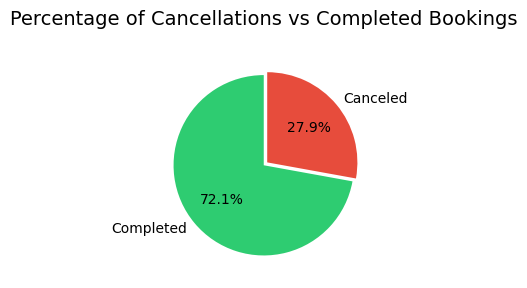

In [57]:
plt.subplot(1, 2, 1)
cancellation_counts = df['IsCanceled'].value_counts()
plt.pie(cancellation_counts, labels=['Completed', 'Canceled'], autopct='%1.1f%%',
        startangle=90, colors=['#2ecc71', '#e74c3c'], explode=[0, 0.05])
plt.title('Percentage of Cancellations vs Completed Bookings', fontsize=14, pad=20)

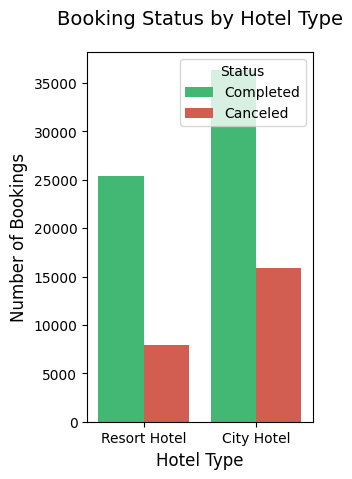

In [58]:
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='hotel', hue='IsCanceled', palette=['#2ecc71', '#e74c3c']) # تعديل اسم العمود هنا
plt.title('Booking Status by Hotel Type', fontsize=14, pad=20)
plt.xlabel('Hotel Type', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.legend(title='Status', labels=['Completed', 'Canceled'])

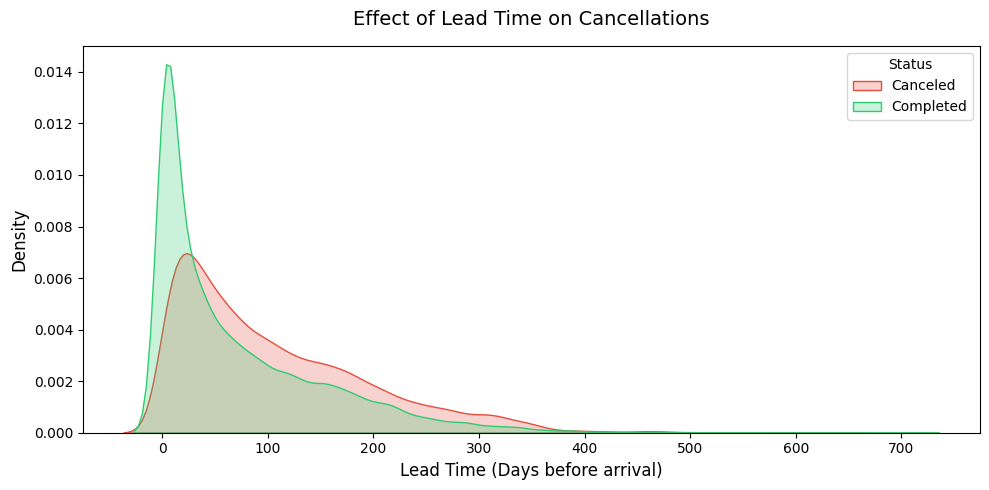

In [59]:
plt.figure(figsize=(10, 5))


sns.kdeplot(data=df, x='LeadTime', hue='IsCanceled', fill=True, palette=['#2ecc71', '#e74c3c'], common_norm=False)

plt.title('Effect of Lead Time on Cancellations', fontsize=14, pad=15)
plt.xlabel('Lead Time (Days before arrival)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Status', labels=['Canceled', 'Completed'])

plt.tight_layout()
plt.show()

/tmp/ipykernel_1364/3065139855.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_cancel_rates = df_temp.groupby('LeadTimeGroup')['IsCanceled'].mean() * 100


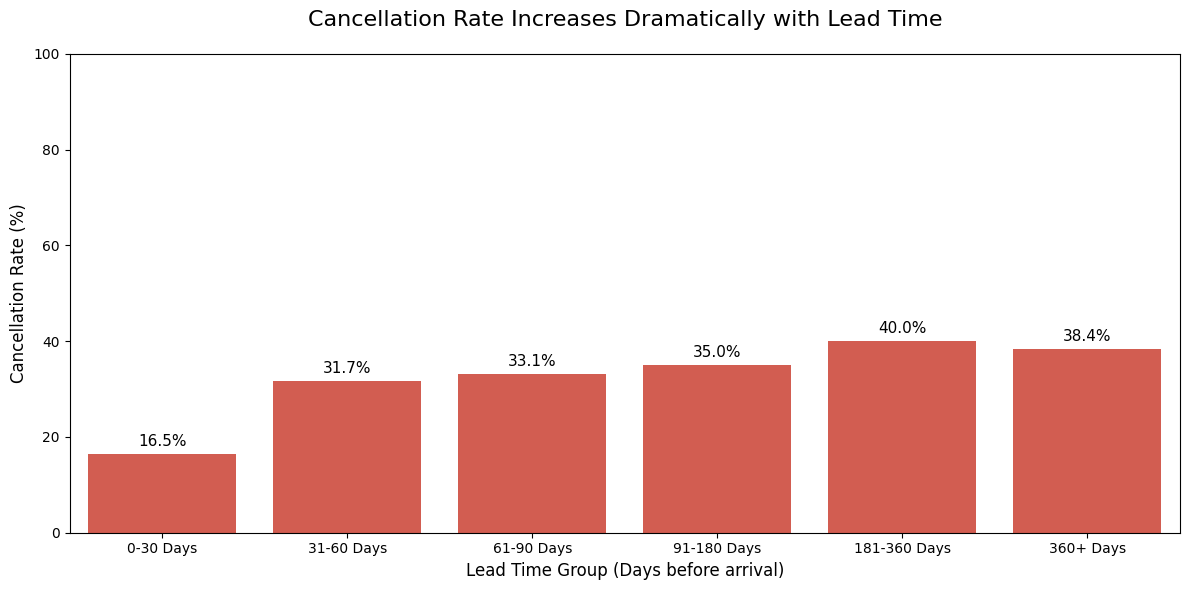

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


bins = [0, 30, 60, 90, 180, 360, np.inf]
labels = ['0-30 Days', '31-60 Days', '61-90 Days', '91-180 Days', '181-360 Days', '360+ Days']


df_temp = df.copy()
df_temp['LeadTimeGroup'] = pd.cut(df_temp['LeadTime'], bins=bins, labels=labels, right=False)


monthly_cancel_rates = df_temp.groupby('LeadTimeGroup')['IsCanceled'].mean() * 100


plt.figure(figsize=(12, 6))
barplot = sns.barplot(x=monthly_cancel_rates.index, y=monthly_cancel_rates.values, color='#e74c3c') # لون أحمر


for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.1f') + '%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=11)

plt.title('Cancellation Rate Increases Dramatically with Lead Time', fontsize=16, pad=20)
plt.xlabel('Lead Time Group (Days before arrival)', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

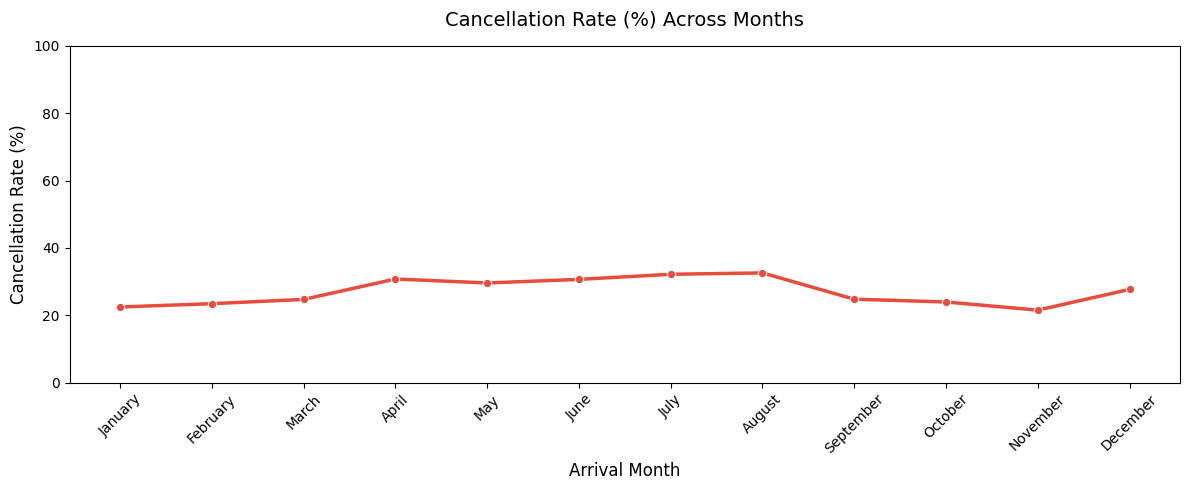

In [60]:
plt.figure(figsize=(12, 5))

ordered_months = ['January', 'February', 'March', 'April', 'May', 'June',
                  'July', 'August', 'September', 'October', 'November', 'December']

monthly_cancel_rate = df.groupby('ArrivalDateMonth')['IsCanceled'].mean().reindex(ordered_months) * 100

sns.lineplot(x=monthly_cancel_rate.index, y=monthly_cancel_rate.values, marker='o', color='#e74c3c', linewidth=2.5)

plt.title('Cancellation Rate (%) Across Months', fontsize=14, pad=15)
plt.xlabel('Arrival Month', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1364/468177411.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=monthly_cancel_rate.index, y=monthly_cancel_rate.values, palette="Reds")


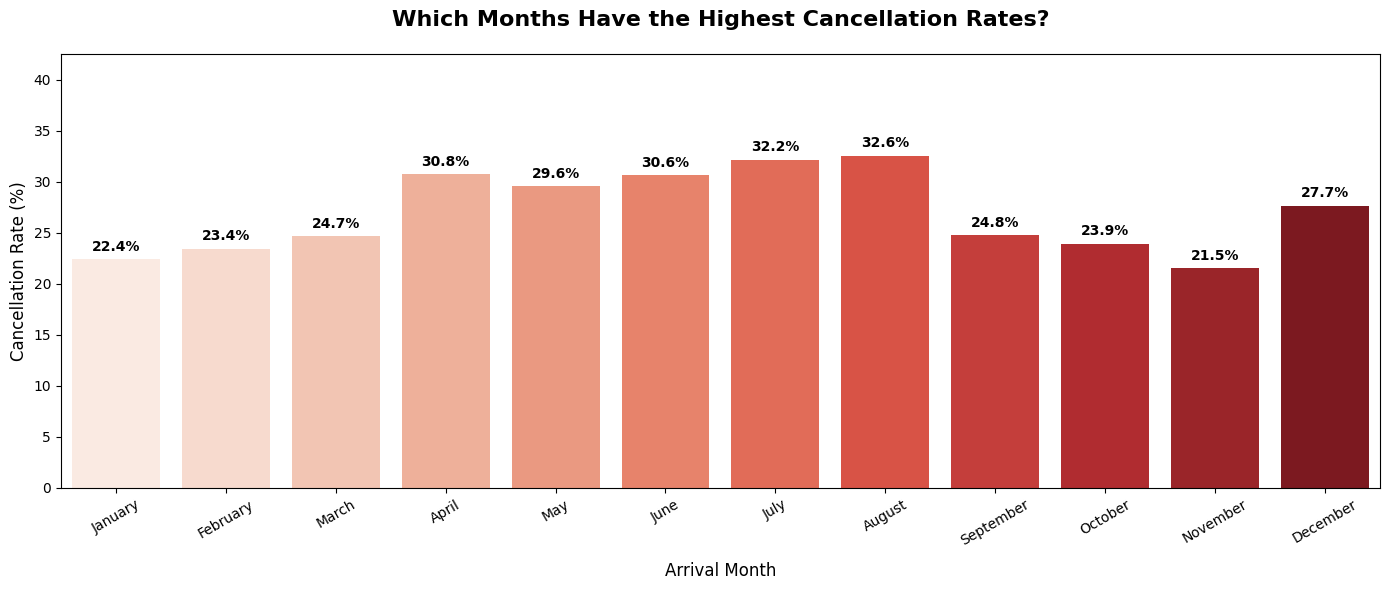

In [64]:


ordered_months = ['January', 'February', 'March', 'April', 'May', 'June',
                  'July', 'August', 'September', 'October', 'November', 'December']
monthly_cancel_rate = df.groupby('ArrivalDateMonth')['IsCanceled'].mean().reindex(ordered_months) * 100

plt.figure(figsize=(14, 6))

barplot = sns.barplot(x=monthly_cancel_rate.index, y=monthly_cancel_rate.values, palette="Reds")

for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.1f') + '%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=10, weight='bold')

plt.title('Which Months Have the Highest Cancellation Rates?', fontsize=16, pad=20, weight='bold')
plt.xlabel('Arrival Month', fontsize=12, labelpad=10)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.xticks(rotation=30)

plt.ylim(0, max(monthly_cancel_rate.values) + 10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1364/4032886410.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=mismatch_cancel_rate.index, y=mismatch_cancel_rate.values, palette=['#2ecc71', '#3498db'])


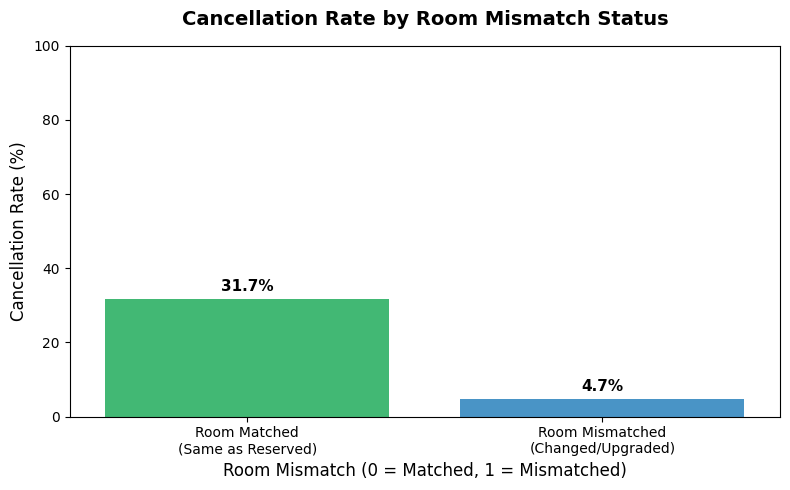

In [65]:


mismatch_cancel_rate = df.groupby('RoomMismatch')['IsCanceled'].mean() * 100

plt.figure(figsize=(8, 5))
barplot = sns.barplot(x=mismatch_cancel_rate.index, y=mismatch_cancel_rate.values, palette=['#2ecc71', '#3498db'])

for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.1f') + '%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=11, weight='bold')

plt.title('Cancellation Rate by Room Mismatch Status', fontsize=14, weight='bold', pad=15)
plt.xlabel('Room Mismatch (0 = Matched, 1 = Mismatched)', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Room Matched\n(Same as Reserved)', 'Room Mismatched\n(Changed/Upgraded)'])
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

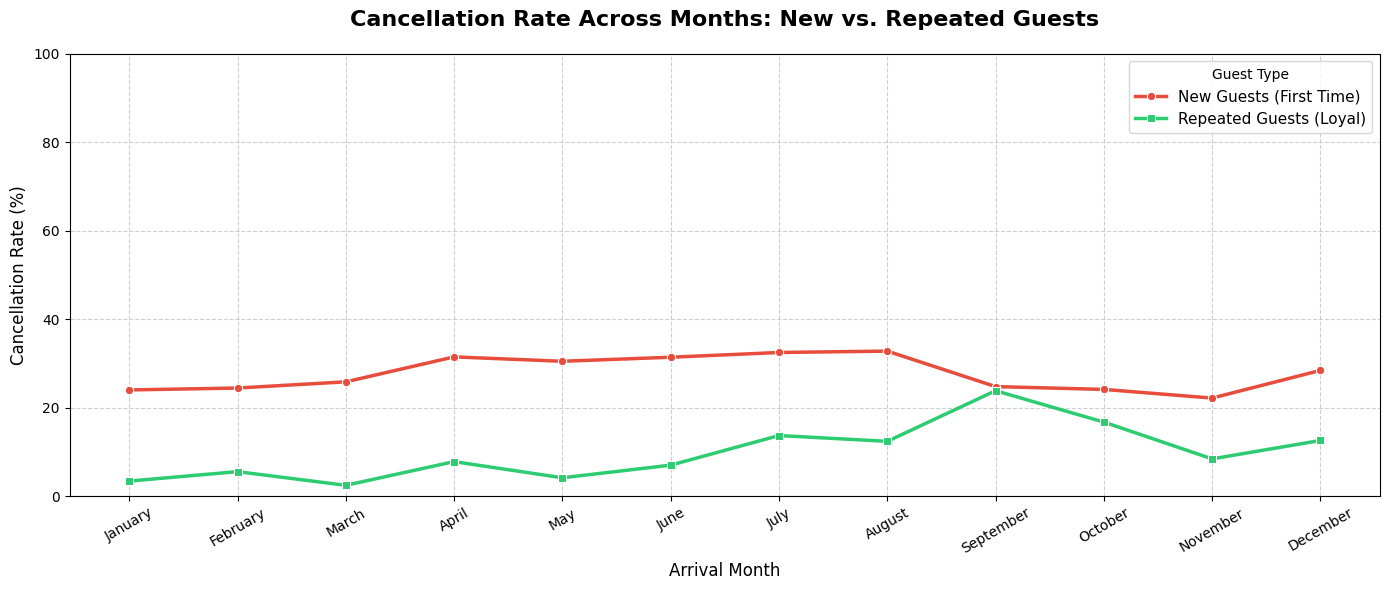

النسب المئوية الدقيقة للإلغاء لكل فئة شهرياً:
IsRepeatedGuest      0     1
ArrivalDateMonth            
January           24.0   3.4
February          24.5   5.6
March             25.9   2.5
April             31.5   7.8
May               30.5   4.2
June              31.4   7.0
July              32.5  13.7
August            32.8  12.4
September         24.8  23.8
October           24.1  16.8
November          22.2   8.4
December          28.4  12.6


In [66]:
ordered_months = ['January', 'February', 'March', 'April', 'May', 'June',
                  'July', 'August', 'September', 'October', 'November', 'December']

guest_monthly_cancel = df.groupby(['ArrivalDateMonth', 'IsRepeatedGuest'])['IsCanceled'].mean().unstack() * 100
guest_monthly_cancel = guest_monthly_cancel.reindex(ordered_months)

plt.figure(figsize=(14, 6))

sns.lineplot(x=guest_monthly_cancel.index, y=guest_monthly_cancel[0], marker='o',
             color='#e74c3c', linewidth=2.5, label='New Guests (First Time)')

sns.lineplot(x=guest_monthly_cancel.index, y=guest_monthly_cancel[1], marker='s',
             color='#2ecc71', linewidth=2.5, label='Repeated Guests (Loyal)')

plt.title('Cancellation Rate Across Months: New vs. Repeated Guests', fontsize=16, weight='bold', pad=20)
plt.xlabel('Arrival Month', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.xticks(rotation=30)
plt.ylim(0, 100)
plt.legend(title='Guest Type', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("النسب المئوية الدقيقة للإلغاء لكل فئة شهرياً:")
print(guest_monthly_cancel.round(1))

/tmp/ipykernel_1364/2655769746.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot1 = sns.barplot(x=deposit_cancel_rate.index, y=deposit_cancel_rate.values, palette='Oranges_r')


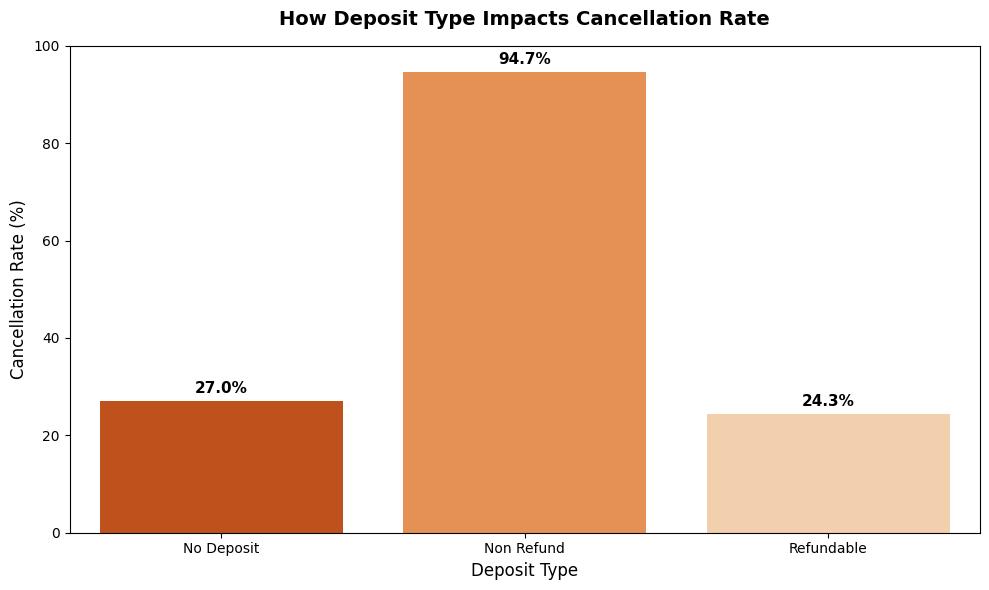

In [67]:


plt.figure(figsize=(10, 6))

deposit_cancel_rate = df.groupby('DepositType')['IsCanceled'].mean() * 100

barplot1 = sns.barplot(x=deposit_cancel_rate.index, y=deposit_cancel_rate.values, palette='Oranges_r')

for p in barplot1.patches:
    barplot1.annotate(format(p.get_height(), '.1f') + '%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=11, weight='bold')

plt.title('How Deposit Type Impacts Cancellation Rate', fontsize=14, weight='bold', pad=15)
plt.xlabel('Deposit Type', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1364/4085549349.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot2 = sns.barplot(x=requests_cancel_rate.index, y=requests_cancel_rate.values, palette='Blues_r')


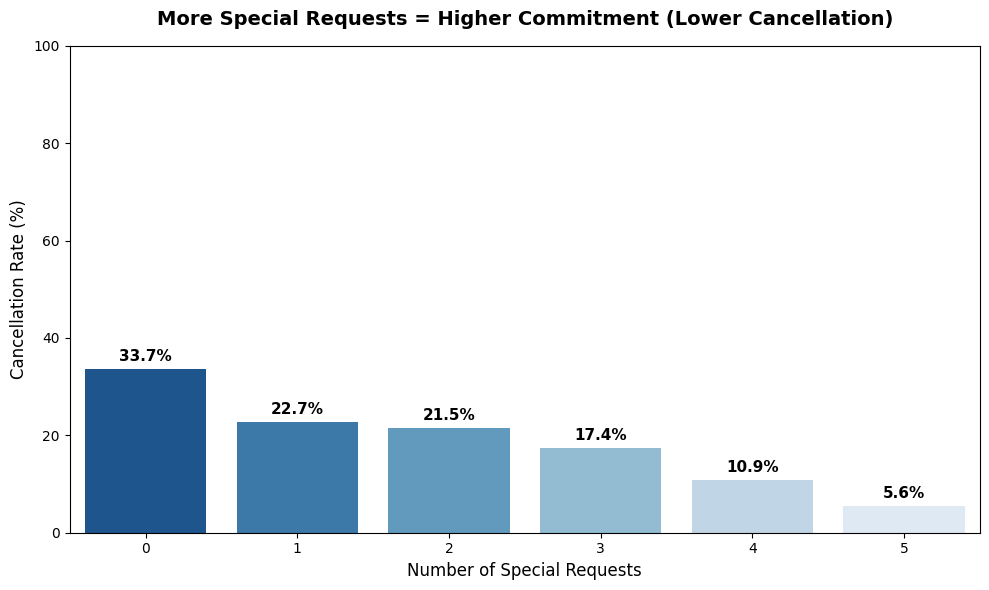

In [68]:
plt.figure(figsize=(10, 6))

requests_cancel_rate = df.groupby('TotalOfSpecialRequests')['IsCanceled'].mean() * 100

barplot2 = sns.barplot(x=requests_cancel_rate.index, y=requests_cancel_rate.values, palette='Blues_r')

for p in barplot2.patches:
    barplot2.annotate(format(p.get_height(), '.1f') + '%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=11, weight='bold')

plt.title('More Special Requests = Higher Commitment (Lower Cancellation)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Number of Special Requests', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

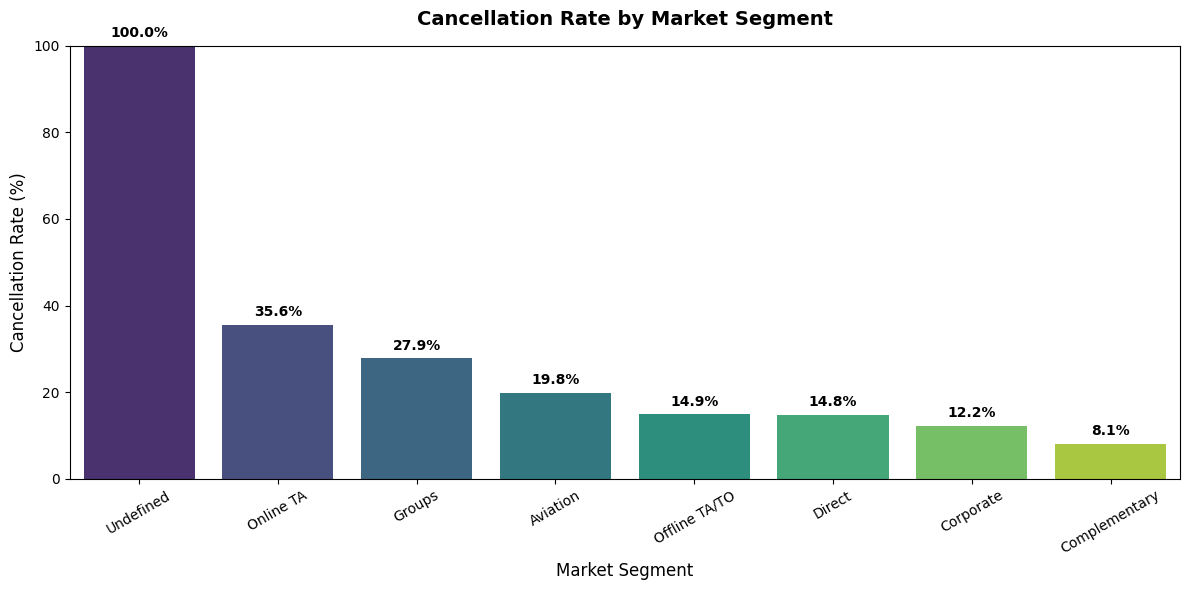

In [70]:
plt.figure(figsize=(12, 6))

market_cancel_rate = df.groupby('MarketSegment')['IsCanceled'].mean().sort_values(ascending=False) * 100

barplot3 = sns.barplot(x=market_cancel_rate.index, y=market_cancel_rate.values, hue=market_cancel_rate.index, palette='viridis', legend=False)

for p in barplot3.patches:
    barplot3.annotate(format(p.get_height(), '.1f') + '%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=10, weight='bold')

plt.title('Cancellation Rate by Market Segment', fontsize=14, weight='bold', pad=15)
plt.xlabel('Market Segment', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.xticks(rotation=30)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

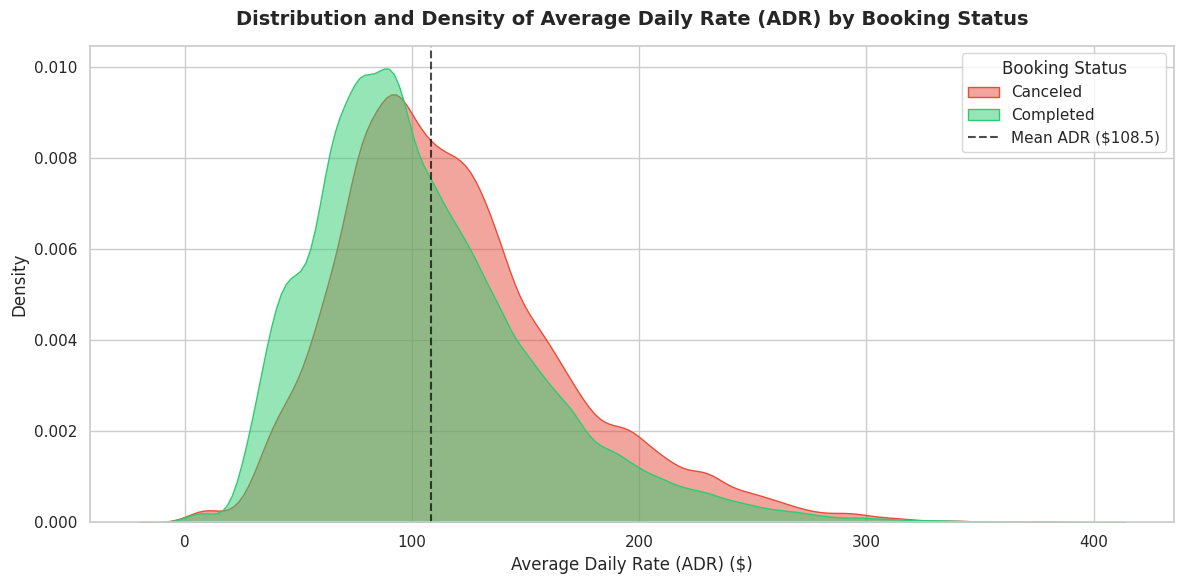

In [74]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# فلترة الأسعار الشاذة فوق 400 لرؤية المنحنى بشكل مثالي
df_filtered_adr = df[df['ADR'] < 400]

# رسم منحنى الكثافة المتداخل
sns.kdeplot(data=df_filtered_adr, x='ADR', hue='IsCanceled', fill=True,
            palette=['#2ecc71', '#e74c3c'], common_norm=False, alpha=0.5)

# إضافة خط يوضح متوسط السعر العام في الداتا لزيادة الاحترافية
mean_adr = df_filtered_adr['ADR'].mean()
plt.axvline(mean_adr, color='black', linestyle='--', alpha=0.7, label=f'Overall Mean ADR: ${mean_adr:.1f}')

# تنسيق العناوين والمحاور
plt.title('Distribution and Density of Average Daily Rate (ADR) by Booking Status', fontsize=14, weight='bold', pad=15)
plt.xlabel('Average Daily Rate (ADR) ($)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Booking Status', labels=['Canceled', 'Completed', f'Mean ADR (${mean_adr:.1f})'])

plt.tight_layout()
plt.show()

/tmp/ipykernel_1364/1893920955.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot_fam = sns.barplot(x=family_cancel.index, y=family_cancel.values, palette='Pastel1')


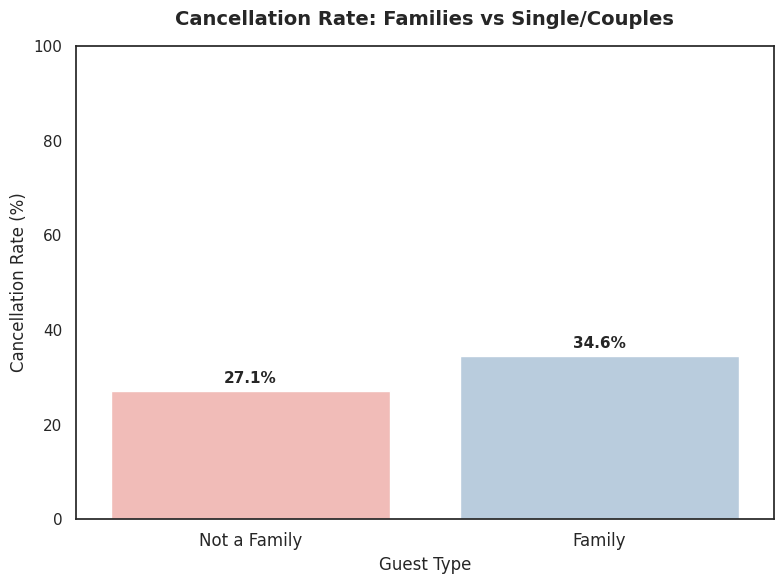

In [77]:


plt.figure(figsize=(8, 6))

family_cancel = df.groupby('IsFamily')['IsCanceled'].mean() * 100

barplot_fam = sns.barplot(x=family_cancel.index, y=family_cancel.values, palette='Pastel1')

تمfor p in barplot_fam.patches:
    barplot_fam.annotate(format(p.get_height(), '.1f') + '%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=11, weight='bold')

plt.title('Cancellation Rate: Families vs Single/Couples', fontsize=14, weight='bold', pad=15)
plt.xticks(ticks=[0, 1], labels=['Not a Family', 'Family'], fontsize=12)
plt.xlabel('Guest Type', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1364/1022768152.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ordered_months, rotation=30)


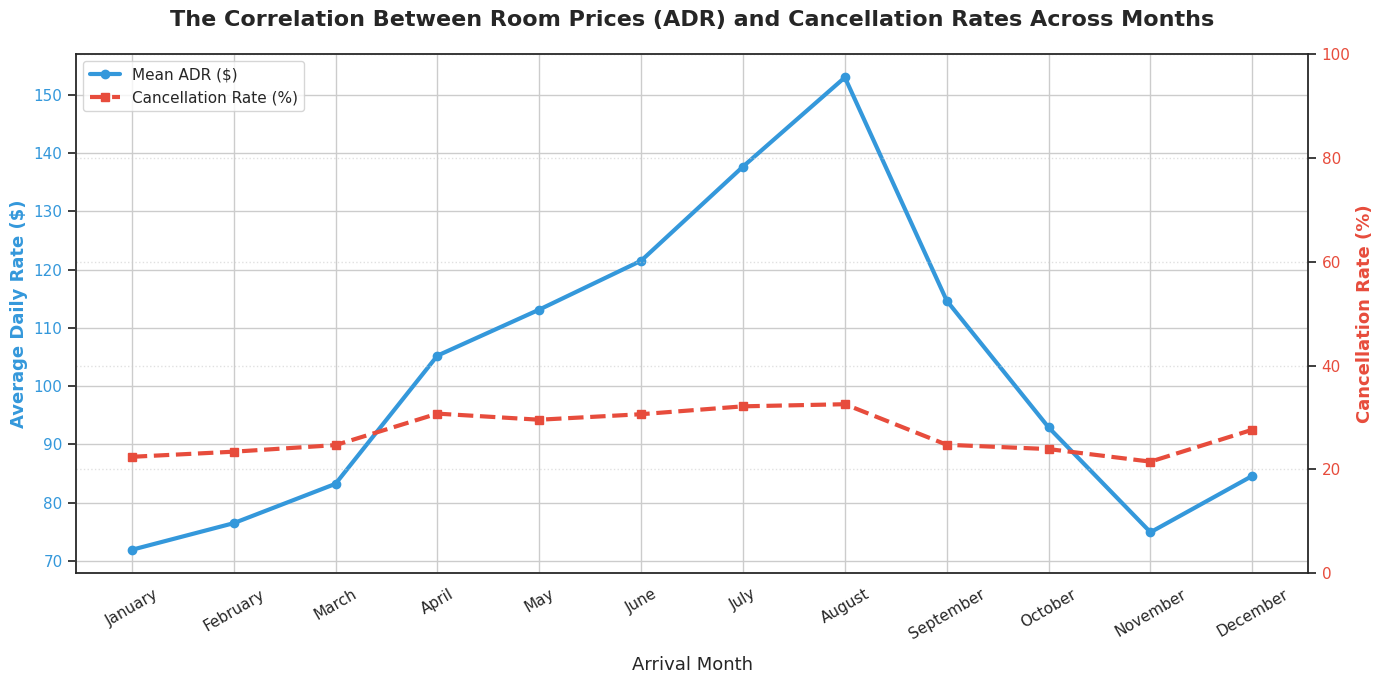

In [75]:


ordered_months = ['January', 'February', 'March', 'April', 'May', 'June',
                  'July', 'August', 'September', 'October', 'November', 'December']

monthly_data = df.groupby('ArrivalDateMonth').agg(
    Mean_ADR=('ADR', 'mean'),
    Cancel_Rate=('IsCanceled', lambda x: x.mean() * 100)
).reindex(ordered_months)

fig, ax1 = plt.subplots(figsize=(14, 7))
sns.set_theme(style="white")

color1 = '#3498db'
ax1.set_xlabel('Arrival Month', fontsize=13, labelpad=10)
ax1.set_ylabel('Average Daily Rate ($)', color=color1, fontsize=13, weight='bold')
line1 = ax1.plot(monthly_data.index, monthly_data['Mean_ADR'], marker='o', color=color1, linewidth=3, label='Mean ADR ($)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticklabels(ordered_months, rotation=30)

ax2 = ax1.twinx()
color2 = '#e74c3c'
ax2.set_ylabel('Cancellation Rate (%)', color=color2, fontsize=13, weight='bold')
line2 = ax2.plot(monthly_data.index, monthly_data['Cancel_Rate'], marker='s', color=color2, linewidth=3, linestyle='--', label='Cancellation Rate (%)')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 100)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11)

plt.title('The Correlation Between Room Prices (ADR) and Cancellation Rates Across Months', fontsize=16, weight='bold', pad=20)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# **Business Questions**

What is the average lead time

In [79]:
mean_lead = df['LeadTime'].mean()
median_lead = df['LeadTime'].median()
std_lead = df['LeadTime'].std()

print(f"Average (Mean) Lead Time: {mean_lead:.1f} days")
print(f"Median Lead Time: {median_lead:.1f} days")
print(f"Standard Deviation of Lead Time: {std_lead:.1f} days")

Average (Mean) Lead Time: 80.7 days
Median Lead Time: 50.0 days
Standard Deviation of Lead Time: 85.9 days


Which hotel type receives more bookings



In [82]:
hotel_counts = df['hotel'].value_counts()
hotel_percentages = df['hotel'].value_counts(normalize=True) * 100

print("Number of Bookings per Hotel Type:")
print(hotel_counts)
print("\nPercentage of Bookings (%):")
print(hotel_percentages.round(1))

Number of Bookings per Hotel Type:
hotel
City Hotel      52321
Resort Hotel    33265
Name: count, dtype: int64

Percentage of Bookings (%):
hotel
City Hotel      61.1
Resort Hotel    38.9
Name: proportion, dtype: float64


Which months have the highest reservations

In [83]:
ordered_months = ['January', 'February', 'March', 'April', 'May', 'June',
                  'July', 'August', 'September', 'October', 'November', 'December']

monthly_bookings = df['ArrivalDateMonth'].value_counts().reindex(ordered_months)
print("Total Bookings per Month:")
print(monthly_bookings)

highest_month = df['ArrivalDateMonth'].mode()[0]
print(f"\nThe month with the highest reservations is: {highest_month}")

Total Bookings per Month:
ArrivalDateMonth
January       4572
February      5955
March         7366
April         7785
May           8209
June          7650
July          9899
August       11099
September     6539
October       6728
November      4844
December      4940
Name: count, dtype: int64

The month with the highest reservations is: August


What factors affect cancellations

Cancellation Rate by Hotel Type:
   - City Hotel: 41.7%
   - Resort Hotel: 27.8%


/tmp/ipykernel_1364/3278168599.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=hotel_cancellation.index, y=hotel_cancellation.values, palette='Blues_r')


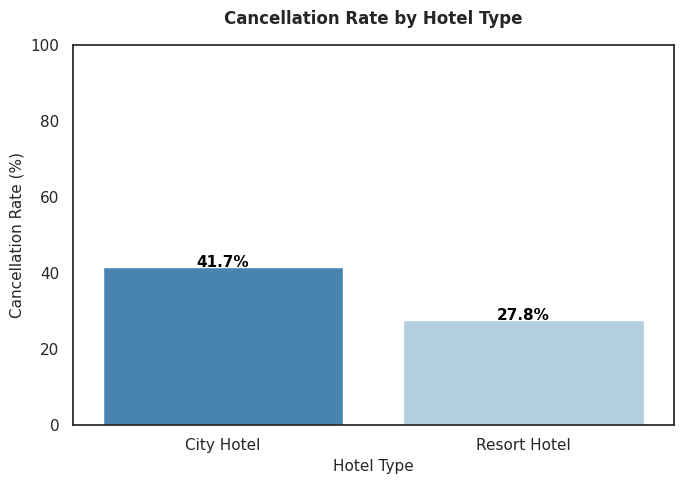

In [93]:
hotel_cancellation = df_combined.groupby('hotel')['IsCanceled'].mean() * 100
print("Cancellation Rate by Hotel Type:")
for hotel, rate in hotel_cancellation.items():
    print(f"   - {hotel}: {rate:.1f}%")



plt.figure(figsize=(7, 5))
ax = sns.barplot(x=hotel_cancellation.index, y=hotel_cancellation.values, palette='Blues_r')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                ha='center', va='center', fontsize=11, weight='bold', color='black')

plt.title('Cancellation Rate by Hotel Type', fontsize=12, weight='bold', pad=15)
plt.ylabel('Cancellation Rate (%)', fontsize=11)
plt.xlabel('Hotel Type', fontsize=11)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Cancellation Rate by Guest Type:
   - Single / Couples (Not a Family): 37.2%
   - Families: 34.9%
--------------------------------------------------


/tmp/ipykernel_1364/1794511051.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=family_cancellation.index, y=family_cancellation.values, palette='Set2')


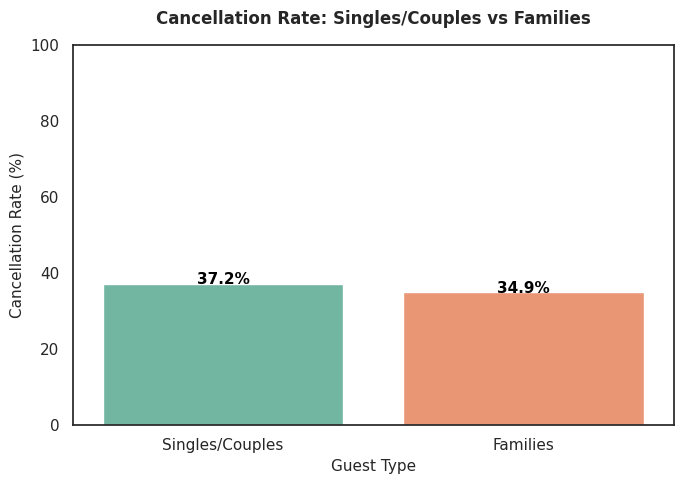

In [94]:


if 'IsFamily' not in df_combined.columns:
    df_combined['IsFamily'] = ((df_combined['Children'] > 0) | (df_combined['Babies'] > 0)).astype(int)

family_cancellation = df_combined.groupby('IsFamily')['IsCanceled'].mean() * 100
print("Cancellation Rate by Guest Type:")
print(f"   - Single / Couples (Not a Family): {family_cancellation[0]:.1f}%")
print(f"   - Families: {family_cancellation[1]:.1f}%")
print("-" * 50)

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=family_cancellation.index, y=family_cancellation.values, palette='Set2')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                ha='center', va='center', fontsize=11, weight='bold', color='black')

plt.title('Cancellation Rate: Singles/Couples vs Families', fontsize=12, weight='bold', pad=15)
plt.xticks(ticks=[0, 1], labels=['Singles/Couples', 'Families'])
plt.ylabel('Cancellation Rate (%)', fontsize=11)
plt.xlabel('Guest Type', fontsize=11)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Cancellation Rate based on Customer History:
   - Guests with NO previous cancellations: 33.9%
   - Guests WITH previous cancellations: 91.6%


/tmp/ipykernel_1364/1270339652.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=history_cancellation.index, y=history_cancellation.values, palette='vlag')


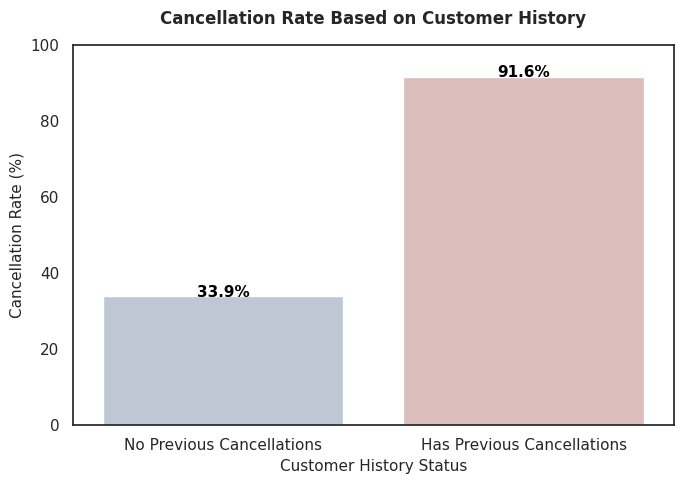

In [95]:
df_combined['Had_Previous_Cancellations'] = df_combined['PreviousCancellations'].apply(lambda x: 1 if x > 0 else 0)
history_cancellation = df_combined.groupby('Had_Previous_Cancellations')['IsCanceled'].mean() * 100
print("Cancellation Rate based on Customer History:")
print(f"   - Guests with NO previous cancellations: {history_cancellation[0]:.1f}%")
print(f"   - Guests WITH previous cancellations: {history_cancellation[1]:.1f}%")

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=history_cancellation.index, y=history_cancellation.values, palette='vlag')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                ha='center', va='center', fontsize=11, weight='bold', color='black')

plt.title('Cancellation Rate Based on Customer History', fontsize=12, weight='bold', pad=15)
plt.xticks(ticks=[0, 1], labels=['No Previous Cancellations', 'Has Previous Cancellations'])
plt.ylabel('Cancellation Rate (%)', fontsize=11)
plt.xlabel('Customer History Status', fontsize=11)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Cancellation Rate by Market Segment:
   - Undefined: 100.0%
   - Groups: 61.1%
   - Online TA: 36.7%
   - Offline TA/TO: 34.3%
   - Aviation: 21.9%
   - Corporate: 18.7%
   - Direct: 15.3%
   - Complementary: 13.1%


/tmp/ipykernel_1364/3503381135.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=segment_ordered.values, y=segment_ordered.index, palette='Reds_r')


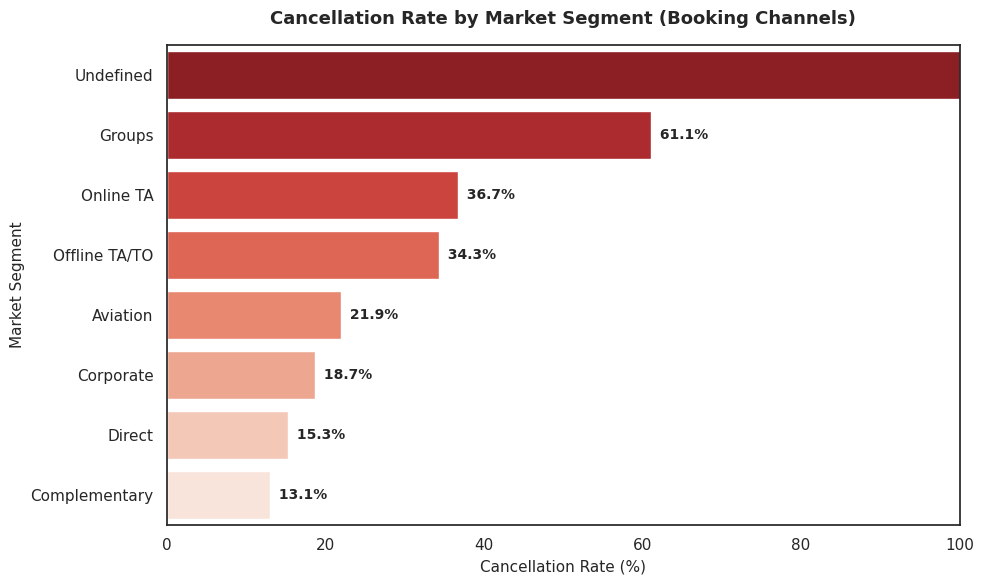

In [96]:
segment_cancellation = df_combined.groupby('MarketSegment')['IsCanceled'].mean() * 100
print("Cancellation Rate by Market Segment:")
for segment, rate in segment_cancellation.sort_values(ascending=False).items():
    print(f"   - {segment}: {rate:.1f}%")

plt.figure(figsize=(10, 6))
segment_ordered = segment_cancellation.sort_values(ascending=False)
ax = sns.barplot(x=segment_ordered.values, y=segment_ordered.index, palette='Reds_r')

for p in ax.patches:
    ax.annotate(f" {p.get_width():.1f}%", (p.get_width() + 0.5, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, weight='bold')

plt.title('Cancellation Rate by Market Segment (Booking Channels)', fontsize=13, weight='bold', pad=15)
plt.xlabel('Cancellation Rate (%)', fontsize=11)
plt.ylabel('Market Segment', fontsize=11)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

Overall Baseline Cancellation Rate: 37.0%


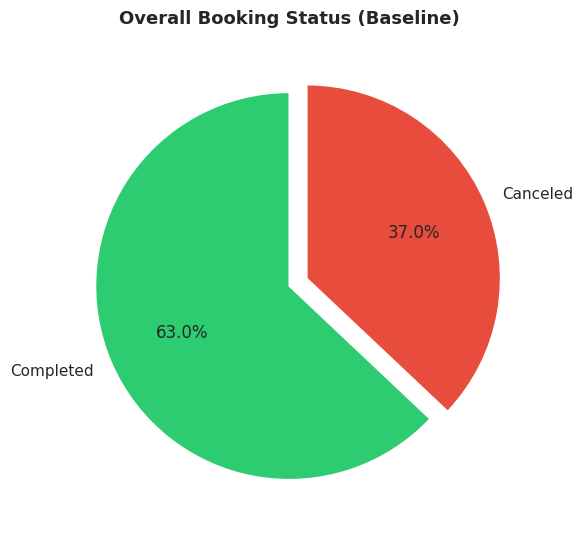

In [97]:
overall_cancellation = df_combined['IsCanceled'].mean() * 100
print(f"Overall Baseline Cancellation Rate: {overall_cancellation:.1f}%")

plt.figure(figsize=(6, 6))
plt.pie([100 - overall_cancellation, overall_cancellation],
        labels=['Completed', 'Canceled'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#2ecc71', '#e74c3c'],
        explode=(0, 0.1))

plt.title('Overall Booking Status (Baseline)', fontsize=13, weight='bold', pad=15)
plt.tight_layout()
plt.show()

Which countries generate the largest number of bookings

In [84]:
top_countries = df['Country'].value_counts().head(5)
top_countries_pct = (df['Country'].value_counts(normalize=True).head(5) * 100).round(1)

print("Top 5 Countries Generating Bookings:")
for country, count, pct in zip(top_countries.index, top_countries.values, top_countries_pct.values):
    print(f"Country: {country} -> Bookings: {count} ({pct}%)")

Top 5 Countries Generating Bookings:
Country: PRT -> Bookings: 26026 (30.6%)
Country: GBR -> Bookings: 10360 (12.2%)
Country: FRA -> Bookings: 8785 (10.3%)
Country: ESP -> Bookings: 7181 (8.4%)
Country: DEU -> Bookings: 5366 (6.3%)


# **💡 Final Business Recommendations**

1. **Optimize Cancellation Policies for Online Channels:** Implement stricter cancellation terms (such as a 10% non-refundable deposit) specifically for **Online TA** bookings with a **Lead Time greater than 50 days** to filter out indecisive reservations.
2. **Promote Direct Bookings:** Since direct bookings display highly stable behavior (low cancellation rate around 14.8%), offer incentives—such as a 5% discount or a complimentary breakfast—on the hotel's official website to steer traffic away from third-party commission-heavy agencies.
3. **Value-Added Pricing in Peak Seasons:** Instead of simply hiking room rates (`ADR`) in July and August, package the rooms with exclusive perks or dining vouchers. This enhances the perceived "Value for Money" and deters guests from canceling in search of cheaper options.
4. **Leverage Special Requests as Engagement Tools:** Reservations with zero special requests have the highest cancellation rates. Implement automated pre-arrival emails 14 days prior to arrival asking: *"How can we personalize your stay?"*. This simple touch increases customer attachment and locks in their commitment.
5. **Concentrate Ad Spend on Top 5 Geographies:** Focus marketing budgets heavily on Portugal, the UK, France, Spain, and Germany. Ensure language accessibility on the booking platform and multilingual staff at reception, as these five nations account for over **67%** of the hotel's entire customer base.